In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()  # 현재 작업 경로를 기준으로 .env를 로드
api_key = os.getenv("GOOGLE_API_KEY")

In [25]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, SystemMessage


model = init_chat_model("gemini-2.5-flash", timeout = 30,api_key = api_key,model_provider="google_genai",temperature=0.7)

# 시스템 역할과 사용자 요청 메시지 생성
system_msg = SystemMessage("당신은 실습 코드를 차분히 설명하는 Assistant입니다.")
human_msg = HumanMessage("안녕하세요. 오늘은 LangGraph 기초를 공부하고 싶어요.")

# 모델 호출을 위한 입력 리스트 구성
messages = [system_msg, human_msg]
response = model.invoke(messages)  # AIMessage 타입 응답
response

AIMessage(content='안녕하세요! LangGraph 기초를 함께 공부해볼까요? LangGraph는 복잡한 LLM 기반 애플리케이션, 특히 대화형 에이전트나 여러 단계를 거쳐 작업을 수행하는 시스템을 구축하는 데 매우 강력한 도구입니다.\n\n### LangGraph란 무엇인가요?\n\nLangGraph는 LangChain을 기반으로 하며, **상태(State)를 가진 유한 상태 기계(Finite State Machine) 또는 방향성 그래프(Directed Graph)를 사용하여 LLM 애플리케이션의 흐름을 정의**할 수 있게 해줍니다. 쉽게 말해, LLM이 여러 단계에 걸쳐 복잡한 작업을 수행해야 할 때, 각 단계에서 무엇을 할지, 어떤 조건에서 다음 단계로 넘어갈지 등을 명확하게 설계하고 실행할 수 있도록 돕는 프레임워크입니다.\n\n**주요 특징:**\n\n1.  **상태 관리 (State Management):** 애플리케이션 전체에서 공유되는 상태(정보)를 정의하고, 각 단계에서 이 상태를 읽거나 업데이트할 수 있습니다. 이는 대화 이력, 중간 결과 등을 관리하는 데 필수적입니다.\n2.  **노드 (Nodes):** 그래프의 각 "점"으로, 특정 작업을 수행하는 함수나 체인입니다. 예를 들어, "LLM 호출", "도구 사용", "데이터베이스 조회" 등이 노드가 될 수 있습니다.\n3.  **엣지 (Edges):** 노드 간의 "화살표"로, 작업의 흐름을 정의합니다. 다음 노드로 무조건 이동하는 `Normal Edge`와 특정 조건에 따라 다음 노드를 결정하는 `Conditional Edge`가 있습니다.\n4.  **루프 (Loops):** LangGraph의 가장 큰 장점 중 하나는 그래프 내에서 루프를 만들 수 있다는 것입니다. 예를 들어, 에이전트가 도구를 사용한 후 결과가 만족스럽지 않으면 다시 생각하고 다른 도구를 시도하는 등의 반복적인 작업을 설계할 수 있습니다.\n\n### 왜 LangGraph를 사용해야 할까요?\n\n* 

In [26]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

# 이전 발화를 포함한 멀티턴 컨텍스트 구성
messages = [
    SystemMessage("당신은 친절한 어시스턴트입니다."),
    HumanMessage("일본의 수도는 어디인가요?"),
    AIMessage("일본의 수도는 도쿄입니다."),
    HumanMessage("한 문장 영어로 바꿔줘."),
]

response = model.invoke(messages)
print(response.content)

네, "일본의 수도는 도쿄입니다."를 영어로 바꾸면 다음과 같습니다.

**The capital of Japan is Tokyo.**


## 메시지 타입 정리
LangChain에서는 대화 맥락을 명확히 다루기 위해 네 가지 대표 메시지 클래스를 사용합니다. 각 타입의 역할을 구분하면 프롬프트 설계가 훨씬 깔끔해집니다.

| 메시지 타입 | 역할 | 주로 쓰는 시점 |
|---|---|---|
| SystemMessage | 모델의 역할/규칙 정의 | 대화 시작 시 기본 정책 설정 |
| HumanMessage | 사용자 입력 표현 | 질문, 요청, 지시 전달 |
| AIMessage | 모델이 생성한 응답 | 이전 응답 기록 및 후속 추론 연결 |
| ToolMessage | 도구 실행 결과 전달 | 함수/툴 호출 결과를 모델에 재주입할 때 |

In [27]:
# 메시지 메타데이터 활용 예제
# content 외에 name/id를 붙여서 추적 가능성을 높일 수 있습니다.

# 실서비스에서는 로깅, 사용자 구분, 분석 파이프라인에서 유용합니다.


# 메타 필드를 포함해 HumanMessage 생성
human_msg = HumanMessage(
    content="다음 주 학습 계획을 같이 정리해줘",
    name="yunseo",  # 발신자 식별값
    id="msg_20260320_01",  # 메시지 트래킹용 ID
)

human_msg

HumanMessage(content='다음 주 학습 계획을 같이 정리해줘', additional_kwargs={}, response_metadata={}, name='yunseo', id='msg_20260320_01')

In [28]:
response = model.invoke([human_msg])
response

AIMessage(content='네, 다음 주 학습 계획을 효율적으로 세울 수 있도록 도와드릴게요! 어떤 과목들을 공부해야 하는지, 특별히 집중하고 싶은 부분이 있는지 (예: 중간고사 대비, 특정 과목 보충, 과제 마무리 등) 알려주시면 더 구체적인 계획을 세울 수 있습니다.\n\n우선, 일반적인 학습 계획 틀을 먼저 제시해 드릴게요. 이 틀을 바탕으로 본인의 상황에 맞춰 내용을 채워나가시면 됩니다.\n\n---\n\n### **다음 주 학습 계획 (예시)**\n\n**🎯 목표 설정:**\n*   이번 주에 꼭 달성하고 싶은 학습 목표 2~3가지 정하기 (예: 수학 3단원 마스터, 영어 단어 100개 암기, 역사 보고서 완성 등)\n*   **[여기에 본인의 목표를 적어주세요]**\n\n**🗓️ 1단계: 정보 수집 및 우선순위 정하기**\n\n다음 질문에 답하면서 이번 주에 해야 할 일들을 정리해 보세요.\n\n1.  **공부해야 할 과목 목록:** (예: 국어, 영어, 수학, 과학, 사회, 선택 과목 등)\n    *   **[여기에 과목들을 적어주세요]**\n2.  **각 과목별 주요 학습 내용 및 목표:** (예: 수학 - 미적분 개념 복습 및 문제 풀이, 영어 - 단어 암기 및 독해 연습, 과학 - 실험 보고서 작성)\n    *   **[여기에 내용을 적어주세요]**\n3.  **다음 주에 제출해야 할 과제나 시험:** (예: 영어 단어 시험, 국어 수행평가, 과학 실험 보고서 마감)\n    *   **[여기에 내용을 적어주세요]**\n4.  **우선순위:** (가장 중요하거나 어려운 과목/내용은 무엇인가요?)\n    *   **[여기에 우선순위를 적어주세요]**\n5.  **하루에 학습 가능한 시간:** (수업 시간 외 순수하게 집중할 수 있는 시간)\n    *   **[여기에 시간을 적어주세요]**\n\n---\n\n**🗓️ 2단계: 주간 학습 시간표 구성 (예시)**\n\n위에서 정리한 내용을 바탕으로 아래 시간표에 채워 넣어 보세요.\n

In [29]:
# 단일 프롬프트 문자열로 모델 호출
response = model.invoke("캐나다의 수도는?")
print(f"Type: {type(response)}")
print(f"Content: {response.content}")

Type: <class 'langchain_core.messages.ai.AIMessage'>
Content: 캐나다의 수도는 **오타와(Ottawa)** 입니다.


## 도구 호출 메시지 흐름
도구 호출 지원 모델은 `AIMessage`의 `tool_calls`를 통해 외부 함수를 실행할 수 있습니다.

흐름 요약:
1. 사용자 요청 전달
2. 모델이 도구 호출 계획 생성
3. 도구 실행 결과 반환
4. 모델이 최종 응답 작성

In [30]:
from langchain.messages import AIMessage, HumanMessage, ToolMessage

# 도구 호출 계획이 들어간 AIMessage 생성
ai_message = AIMessage(
    content="",
    tool_calls=[
        {"name": "get_weather", "args": {"location": "부산"}, "id": "call_987"}
    ],
)
ai_message

AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'get_weather', 'args': {'location': '부산'}, 'id': 'call_987', 'type': 'tool_call'}], invalid_tool_calls=[])

In [31]:
# 도구 결과를 ToolMessage로 포장
weather_result = "흐림, 섭씨 18도"
tool_message = ToolMessage(
    content=weather_result, tool_call_id="call_987"  # 동일한 호출 ID를 연결
 )
tool_message

ToolMessage(content='흐림, 섭씨 18도', tool_call_id='call_987')

In [32]:
# 사용자 요청과 도구 관련 메시지를 순서대로 전달
messages = [
    HumanMessage("부산 날씨 알려줘"),
    ai_message,  # 모델이 제안한 도구 호출
    tool_message,  # 도구 실행 결과 데이터
 ]

response = model.invoke(messages)  # 결과를 반영한 최종 응답 생성
print(response.content)

부산은 현재 흐리고, 기온은 섭씨 18도입니다.


## StateGraph 시작하기
`StateGraph`에 상태 타입을 지정한 뒤 노드/엣지를 추가하고 `compile()`로 실행 그래프를 만듭니다.

`START`와 `END`는 각각 시작점과 종료점을 의미합니다.

## LangGraph 구성 요소
LangGraph는 상태(State)를 중심으로 노드(Node)와 엣지(Edge)를 연결해 워크플로우를 만듭니다.

- State: 공유 데이터
- Node: 처리 로직
- Edge: 다음 실행 경로

In [33]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 그래프 내 공유 상태 스키마 정의
class InternalState(TypedDict):
    input: str  # 외부 입력 문자열
    result: str  # 처리 결과 문자열


# 상태 타입을 사용해 그래프 빌더 초기화
builder = StateGraph(InternalState)


# 상태를 받아 결과 필드를 계산하는 노드
def process_node(state: InternalState):
    return {"result": f"처리됨: {state['input']}"}


# 노드 이름과 함수를 매핑하여 등록
builder.add_node("process", process_node)

# 실행 경로를 시작점 -> process -> 종료점으로 연결
builder.add_edge(START, "process")
builder.add_edge("process", END)

# 실행 가능한 형태로 컴파일
graph = builder.compile()

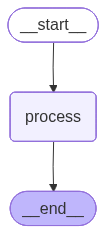

In [34]:
graph

In [35]:
# 샘플 입력으로 그래프 동작 확인
result = graph.invoke({"input": "LangGraph 연습"})
print(result)

{'input': 'LangGraph 연습', 'result': '처리됨: LangGraph 연습'}


In [36]:
from typing_extensions import TypedDict


# TypedDict 기반 상태 구조 선언
class BasicState(TypedDict):
    name: str  # 사용자 이름 값
    age: int  # 사용자 나이 값
    messages: list[str]  # 대화 문장 목록

In [37]:

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 리듀서 미지정 상태: 키 단위 기본 덮어쓰기
class State(TypedDict):
    foo: int  # 숫자 필드
    bar: str  # 문자열 필드


def node_1(state: State):
    """첫 번째 노드: foo를 새 값으로 갱신"""
    print(f"node_1 - 현재 상태: {state}")
    return {"foo": 2}  # foo만 변경


def node_2(state: State):
    """두 번째 노드: bar를 새 값으로 갱신"""
    print(f"node_2 - 현재 상태: {state}")
    return {"bar": "좋은 하루"}  # bar만 변경


# 그래프 빌더 생성
builder = StateGraph(State)

# 실행 노드 등록
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# 실행 순서 연결
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# 컴파일 후 초기 상태로 실행
graph = builder.compile()
result = graph.invoke({"foo": 7, "bar": "초기 메시지"})
print(f"최종 결과: {result}")

node_1 - 현재 상태: {'foo': 7, 'bar': '초기 메시지'}
node_2 - 현재 상태: {'foo': 2, 'bar': '초기 메시지'}
최종 결과: {'foo': 2, 'bar': '좋은 하루'}


In [38]:
# Annotated의 두 번째 인자에는 상태 병합 리듀서를 지정합니다.
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END


# Annotated로 필드별 병합 방식 정의
# add 리듀서: 새 리스트를 기존 리스트 뒤에 결합
class State(TypedDict):
    foo: int  # 기본은 덮어쓰기
    bar: Annotated[list[str], add]  # 리스트 누적 병합


def node_1(state: State):
    """첫 번째 노드: foo 값 수정"""
    print(f"node_1 - 현재 상태: {state}")
    return {"foo": 5}


def node_2(state: State):
    """두 번째 노드: bar에 항목 추가"""
    print(f"node_2 - 현재 상태: {state}")
    return {"bar": ["추가 메모"]}  # add 리듀서로 누적


# 그래프 구성
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()

# 초기 상태를 넣어 병합 결과 확인
result = graph.invoke({"foo": 9, "bar": ["시작 항목"]})
print(f"최종 결과: {result}")

node_1 - 현재 상태: {'foo': 9, 'bar': ['시작 항목']}
node_2 - 현재 상태: {'foo': 5, 'bar': ['시작 항목']}
최종 결과: {'foo': 5, 'bar': ['시작 항목', '추가 메모']}


In [39]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END


# add_messages 리듀서를 사용하는 메시지 상태
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]  # 메시지 자동 누적


def chatbot_node(state: MessagesState):
    """마지막 메시지를 읽어 응답을 추가"""
    last_message = state["messages"][-1]  # 최근 메시지 추출
    response = f"메시지를 받았습니다: {last_message.content}"
    return {"messages": [AIMessage(content=response)]}  # AI 응답 추가


# 단일 노드 챗봇 그래프 정의
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

# 사용자 입력 한 건으로 실행
result = graph.invoke({"messages": [HumanMessage(content="이번 주 학습 목표를 정리해줘")]} )

# 누적 메시지 출력
print("메시지 목록:")
for msg in result["messages"]:
    print(f"- {msg.__class__.__name__}: {msg.content}")

메시지 목록:
- HumanMessage: 이번 주 학습 목표를 정리해줘
- AIMessage: 메시지를 받았습니다: 이번 주 학습 목표를 정리해줘


## 노드 인자 요약
노드 함수는 보통 `state`를 필수로 받고, 필요하면 `config`, `runtime`도 사용할 수 있습니다.

- state: 현재 상태 데이터
- config: 실행 설정
- runtime: 실행 컨텍스트

In [40]:
from typing_extensions import TypedDict
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    input: str  # 입력 텍스트
    results: str  # 처리 결과


def plain_node(state: State):
    """state만 이용하는 기본 노드"""
    return {"results": f"처리됨: {state['input']}"}


def node_with_config(state: State, config: RunnableConfig):
    """config 메타데이터를 읽는 노드"""
    # thread_id가 없으면 unknown으로 대체
    thread_id = config.get("configurable", {}).get("thread_id", "unknown")
    print(f"Thread ID: {thread_id}")
    return {"results": f"안녕, {state['input']}!"}


# 순차 실행 그래프 정의
builder = StateGraph(State)
builder.add_node("plain_node", plain_node)
builder.add_node("node_with_config", node_with_config)
builder.add_edge(START, "plain_node")
builder.add_edge("plain_node", "node_with_config")
builder.add_edge("node_with_config", END)

graph = builder.compile()

# 상태 값과 config를 함께 넣어 실행
result = graph.invoke(
    {"input": "워크플로우 점검"}, config={"configurable": {"thread_id": "session-42"}}
)
print(f"결과: {result}")

Thread ID: session-42
결과: {'input': '워크플로우 점검', 'results': '안녕, 워크플로우 점검!'}


## 엣지 종류 정리
- **일반 엣지 (`add_edge`)**: 항상 같은 다음 노드로 이동합니다.
- **조건부 엣지 (`add_conditional_edges`)**: 라우팅 함수 결과에 따라 분기합니다.

`START`와 `END`는 그래프의 시작점과 종료점을 나타내는 특수 노드입니다.

## 조건부 라우팅 패턴
`add_conditional_edges(source, routing_function, path_map)`를 사용하면 상태 기반 분기를 구성할 수 있습니다.

이 방식은 도구 호출 판단, 입력 검증 분기, 규칙 기반 흐름 제어에 유용합니다.

아래 예제에서는 `value`의 홀짝에 따라 `node_b` 또는 `node_c`로 이동합니다.

In [41]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    value: int  # 분기 판단에 사용할 값
    path: str  # 선택 경로 기록


def node_a(state: State):
    """노드 A: value를 다음 단계로 전달"""
    print("노드 A 실행")
    return {"value": state["value"]}


def node_b(state: State):
    """노드 B: 짝수 분기 처리"""
    print("노드 B 실행 (짝수 경로)")
    return {"path": "짝수"}


def node_c(state: State):
    """노드 C: 홀수 분기 처리"""
    print("노드 C 실행 (홀수 경로)")
    return {"path": "홀수"}


def routing_function(state: State):
    """짝수면 even, 홀수면 odd 반환"""
    if state["value"] % 2 == 0:
        return "even"
    else:
        return "odd"


# 그래프 구성 및 노드 등록
builder = StateGraph(State)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

# 시작 엣지 연결
builder.add_edge(START, "node_a")

# 라우팅 결과에 따른 분기 테이블 지정
builder.add_conditional_edges(
    "node_a", routing_function, {"even": "node_b", "odd": "node_c"}
)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()

# 짝수 입력 테스트
print("=== 짝수 테스트 ===")
result = graph.invoke({"value": 8})
print(f"결과: {result}")

print()

# 홀수 입력 테스트
print("=== 홀수 테스트 ===")
result = graph.invoke({"value": 11})
print(f"결과: {result}")


=== 짝수 테스트 ===
노드 A 실행
노드 B 실행 (짝수 경로)
결과: {'value': 8, 'path': '짝수'}

=== 홀수 테스트 ===
노드 A 실행
노드 C 실행 (홀수 경로)
결과: {'value': 11, 'path': '홀수'}


In [42]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command


class State(TypedDict):
    count: int  # 루프 횟수 카운트
    status: str  # 현재 진행 상태


def decision_node(state: State) -> Command[Literal["continue_node", "end_node"]]:
    """count 값을 보고 다음 노드를 선택"""
    # Command로 상태 업데이트와 이동 대상을 함께 반환
    new_count = state["count"] + 1
    if new_count < 3:
        # 임계값 이전이면 계속 노드로 이동
        return Command(
            update={"count": new_count, "status": "진행 중"}, goto="continue_node"
        )
    else:
        # 임계값 도달 시 종료 노드로 이동
        return Command(update={"count": new_count, "status": "완료"}, goto="end_node")


def continue_node(state: State):
    """중간 단계 노드: 진행 로그 출력"""
    print(f"계속 진행 중... (카운트: {state['count']})")
    return state


def end_node(state: State):
    """마무리 노드: 최종 로그 출력"""
    print(f"종료 노드 도달 (카운트: {state['count']})")
    return state


# 그래프 초기화
builder = StateGraph(State)
builder.add_node("decision_node", decision_node)
builder.add_node("continue_node", continue_node)
builder.add_node("end_node", end_node)

# 루프 경로와 종료 경로 연결
builder.add_edge(START, "decision_node")
builder.add_edge("continue_node", "decision_node")  # continue 후 재평가
builder.add_edge("end_node", END)

graph = builder.compile()

# 초기 상태로 실행
result = graph.invoke({"count": 1, "status": "초기화"})
print(f"최종 상태: {result}")

계속 진행 중... (카운트: 2)
종료 노드 도달 (카운트: 3)
최종 상태: {'count': 3, 'status': '완료'}
